#Proses mendownload dataset gambar

In [16]:
import os
import shutil
import pandas as pd
from tqdm import tqdm
import kagglehub
from google.colab import drive

drive.mount('/content/drive')

dest_base_dir = '/content/drive/MyDrive/deteksi_gambar_ai/dataset'
dest_ai_dir = os.path.join(dest_base_dir, 'AI')
dest_human_dir = os.path.join(dest_base_dir, 'HUMAN')

os.makedirs(dest_ai_dir, exist_ok=True)
os.makedirs(dest_human_dir, exist_ok=True)

print("Mendapatkan informasi dataset dari Kaggle...")
dataset_path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

csv_path = os.path.join(dataset_path, "train.csv")
df = pd.read_csv(csv_path)

df_ai = df[df['label'] == 1]
df_human = df[df['label'] == 0]

print(f"Total data asli di Kaggle -> AI: {len(df_ai)} gambar, Human: {len(df_human)} gambar")

sample_size = 5000
df_ai_sample = df_ai.sample(n=min(sample_size, len(df_ai)), random_state=42)
df_human_sample = df_human.sample(n=min(sample_size, len(df_human)), random_state=42)

def download_and_copy_images(df_sample, dest_folder, class_name):
    print(f"\nMemulai proses pemindahan {len(df_sample)} gambar untuk kelas: {class_name}")

    for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        relative_img_path = row['file_name']

        src_img_path = os.path.join(dataset_path, relative_img_path)

        img_name = os.path.basename(relative_img_path)
        dest_img_path = os.path.join(dest_folder, img_name)

        if os.path.exists(src_img_path):
            if not os.path.exists(dest_img_path):
                shutil.copy(src_img_path, dest_img_path)
        else:
            alternative_path = os.path.join(dataset_path, "train_data", img_name)
            if os.path.exists(alternative_path) and not os.path.exists(dest_img_path):
                shutil.copy(alternative_path, dest_img_path)

download_and_copy_images(df_ai_sample, dest_ai_dir, "AI")
download_and_copy_images(df_human_sample, dest_human_dir, "HUMAN")

print("\n Selesai! Masing-masing 5.000 gambar berhasil disimpan di Google Drive.")
print(f"Total Gambar AI di Drive saat ini: {len(os.listdir(dest_ai_dir))}")
print(f"Total Gambar Human di Drive saat ini: {len(os.listdir(dest_human_dir))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mendapatkan informasi dataset dari Kaggle...
Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
Total data asli di Kaggle -> AI: 39975 gambar, Human: 39975 gambar

Memulai proses pemindahan 5000 gambar untuk kelas: AI


100%|██████████| 5000/5000 [01:04<00:00, 77.66it/s]



Memulai proses pemindahan 5000 gambar untuk kelas: HUMAN


100%|██████████| 5000/5000 [01:08<00:00, 73.14it/s]



 Selesai! Masing-masing 5.000 gambar berhasil disimpan di Google Drive.
Total Gambar AI di Drive saat ini: 5000
Total Gambar Human di Drive saat ini: 5000


In [1]:
!pip install -q transformers[torch] datasets evaluate accelerate scikit-learn tqdm

In [2]:
import os
import torch
import evaluate
import numpy as np
import random
from PIL import Image
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict, Image as DatasetImage
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from google.colab import drive

drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/deteksi_gambar_ai/dataset'
ai_dir = os.path.join(base_dir, 'AI')
human_dir = os.path.join(base_dir, 'HUMAN')

file_paths = []
labels = []

for img_name in os.listdir(human_dir):
    if img_name.endswith(('.jpg', '.jpeg', '.png')):
        file_paths.append(os.path.join(human_dir, img_name))
        labels.append(0)

for img_name in os.listdir(ai_dir):
    if img_name.endswith(('.jpg', '.jpeg', '.png')):
        file_paths.append(os.path.join(ai_dir, img_name))
        labels.append(1)

combined = list(zip(file_paths, labels))
random.seed(42)
random.shuffle(combined)
file_paths, labels = zip(*combined)

print(f"Total gambar ditemukan setelah di-shuffle: {len(file_paths)}")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

def create_hf_dataset(paths, labels):
    return Dataset.from_dict({"image": paths, "label": labels}).cast_column("image", DatasetImage())

raw_datasets = DatasetDict({
    "train": create_hf_dataset(train_paths, train_labels),
    "validation": create_hf_dataset(val_paths, val_labels)
})

model_name = "Smogy/SMOGY-Ai-images-detector"
processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "HUMAN", 1: "AI"},
    label2id={"HUMAN": 0, "AI": 1},
    ignore_mismatched_sizes=True
)

for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

print("✅ Berhasil mengunci bobot dasar Swin. Hanya lapisan klasifikasi yang akan dilatih.")

def transform_fn(examples):
    inputs = processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    inputs["label"] = examples["label"]
    return inputs

raw_datasets.set_transform(transform_fn)

metric_accuracy = evaluate.load("accuracy")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")
metric_f1 = evaluate.load("f1")
metric_roc_auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    probabilities = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)
    ai_probabilities = probabilities[:, 1]

    return {
        "accuracy": metric_accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": metric_precision.compute(predictions=predictions, references=labels, average="binary")["precision"],
        "recall": metric_recall.compute(predictions=predictions, references=labels, average="binary")["recall"],
        "f1": metric_f1.compute(predictions=predictions, references=labels, average="binary")["f1"],
        "roc_auc": metric_roc_auc.compute(prediction_scores=ai_probabilities, references=labels)["roc_auc"]
    }

def data_collator(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "labels": torch.tensor([x["label"] for x in batch])
    }

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/deteksi_gambar_ai/results",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    gradient_checkpointing=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    remove_unused_columns=False,
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=raw_datasets["train"],
    eval_dataset=raw_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n[INFO] Memulai Fine-Tuning Terbimbing...")
trainer.train()

final_model_path = "/content/drive/MyDrive/deteksi_gambar_ai/model"
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)
print(f"\n[SUKSES] Model hasil perbaikan disimpan di: {final_model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total gambar ditemukan setelah di-shuffle: 10000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

✅ Berhasil mengunci bobot dasar Swin. Hanya lapisan klasifikasi yang akan dilatih.

[INFO] Memulai Fine-Tuning Terbimbing...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,3.535060,2.988708,0.202000,0.227106,0.248000,0.237094,0.124211
2,0.418704,0.372513,0.856500,0.823797,0.907000,0.863398,0.934693
3,0.323178,0.308435,0.885500,0.876098,0.898000,0.886914,0.951307


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['swin.encoder.layers.0.blocks.0.attention.q_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.q_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.k_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.k_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.v_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.v_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.o_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.o_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.relative_position_bias.relative_position_bias_table', 'swin.encoder.layers.0.blocks.0.mlp.fc1.weight', 'swin.encoder.layers.0.blocks.0.mlp.fc1.bias', 'swin.encoder.layers.0.blocks.0.mlp.fc2.weight', 'swin.encoder.layers.0.blocks.0.mlp.fc2.bias', 'swin.encoder.layers.0.blocks.1.attention.q_proj.weight', 'swin.encoder.layers.0.blocks.1.attention.q_proj.bias', 'swin.encoder.layers.0.blocks.1.attention.k_proj.weight', 'swin.encode

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[SUKSES] Model hasil perbaikan disimpan di: /content/drive/MyDrive/deteksi_gambar_ai/model


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Memuat model Swin dari: /content/drive/MyDrive/deteksi_gambar_ai/model


Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]


[INFO] Menghitung prediksi pada data validasi...


100%|██████████| 125/125 [01:04<00:00,  1.94it/s]


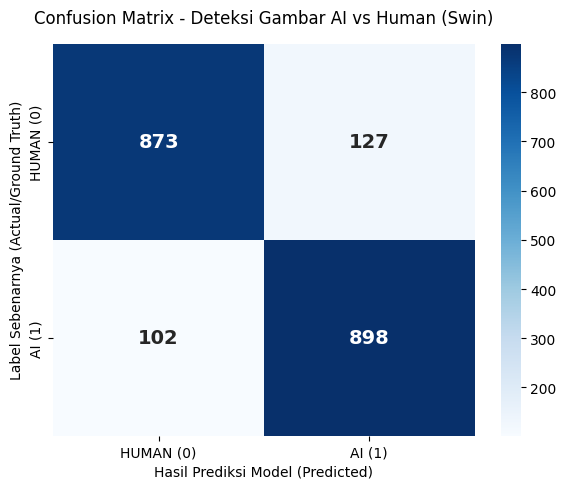


             LAPORAN KLASIFIKASI LENGKAP
              precision    recall  f1-score   support

   HUMAN (0)     0.8954    0.8730    0.8841      1000
      AI (1)     0.8761    0.8980    0.8869      1000

    accuracy                         0.8855      2000
   macro avg     0.8857    0.8855    0.8855      2000
weighted avg     0.8857    0.8855    0.8855      2000



In [3]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoModelForImageClassification, AutoImageProcessor
from google.colab import drive

drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/content/drive/MyDrive/deteksi_gambar_ai/model"
print(f"Memuat model Swin dari: {model_path}")

model = AutoModelForImageClassification.from_pretrained(model_path).to(device)
processor = AutoImageProcessor.from_pretrained(model_path)
model.eval()

y_true = []
y_pred = []

print("\n[INFO] Menghitung prediksi pada data validasi...")
batch_size = 16

for i in tqdm(range(0, len(val_paths), batch_size)):
    batch_paths = val_paths[i:i+batch_size]
    batch_labels = val_labels[i:i+batch_size]

    images = []
    valid_labels = []

    for path, label in zip(batch_paths, batch_labels):
        try:
            img = Image.open(path).convert("RGB")
            images.append(img)
            valid_labels.append(label)
        except Exception as e:
            continue

    if not images:
        continue

    inputs = processor(images, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()

    y_true.extend(valid_labels)
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
labels = ['HUMAN (0)', 'AI (1)']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix - Deteksi Gambar AI vs Human (Swin)', fontsize=12, pad=15)
plt.ylabel('Label Sebenarnya (Actual/Ground Truth)', fontsize=10)
plt.xlabel('Hasil Prediksi Model (Predicted)', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("             LAPORAN KLASIFIKASI LENGKAP")
print("="*60)
print(classification_report(y_true, y_pred, target_names=labels, digits=4))
print("="*60)

Sedang memuat model Swin dari Drive...


Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

Model berhasil dimuat! Siap mendeteksi.



Saving asli.jpg to asli.jpg

Memproses file: "asli.jpg"


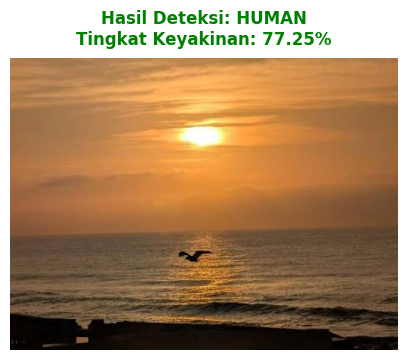

In [14]:
import torch
import io
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import AutoModelForImageClassification, AutoImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "/content/drive/MyDrive/deteksi_gambar_ai/model"

print("Sedang memuat model Swin dari Drive...")
model = AutoModelForImageClassification.from_pretrained(model_path).to(device)
processor = AutoImageProcessor.from_pretrained(model_path)
model.eval()
print("Model berhasil dimuat! Siap mendeteksi.\n")

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\nMemproses file: "{filename}"')

    try:
        img_bytes = uploaded[filename]
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        inputs = processor(img, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probabilities = torch.nn.functional.softmax(logits, dim=-1)

            top_prob, top_lbl_idx = torch.max(probabilities, dim=-1)
            confidence = top_prob.item() * 100
            predicted_label = model.config.id2label[top_lbl_idx.item()]

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')

        text_color = 'green' if predicted_label == "HUMAN" else 'red'

        plt.title(f"Hasil Deteksi: {predicted_label}\nTingkat Keyakinan: {confidence:.2f}%",
                  color=text_color, fontsize=12, weight='bold', pad=10)
        plt.show()

    except Exception as e:
        print(f"Gagal memproses gambar {filename}. Error: {e}")